<a href="https://colab.research.google.com/github/taariq20/816042980COMP3610Assignment2/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Data Preprocessing & Feature Engineering

In [15]:
import os
import sys
import requests
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scipy
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import randint, uniform

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('All imports successful!')

All imports successful!


In [4]:
trip_url  = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
zone_url  = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
trip_file = "yellow_tripdata_2023-01.parquet"
zone_file = "taxi_zone_lookup.csv"

if not os.path.exists(trip_file):
    print("Downloading trip data...")
    r = requests.get(trip_url)
    with open(trip_file, "wb") as f:
        f.write(r.content)
    print("Trip data downloaded.")
else:
    print("Trip data already exists.")

if not os.path.exists(zone_file):
    print("Downloading zone lookup...")
    r = requests.get(zone_url)
    with open(zone_file, "wb") as f:
        f.write(r.content)
    print("Zone lookup downloaded.")
else:
    print("Zone lookup already exists.")

cols_to_load = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID",
    "DOLocationID", "passenger_count", "trip_distance", "fare_amount",
    "tip_amount", "total_amount", "payment_type"
]

df    = pl.read_parquet(trip_file, columns=cols_to_load)
zones = pl.read_csv(zone_file)

print(f"Trip rows: {df.height:,}")
print(f"Zone rows: {zones.height:,}")
print(f"\nSchema:\n{df.schema}")

Trip data downloaded.
Zone lookup downloaded.
Trip rows: 3,066,766
Zone rows: 265

Schema:
Schema({'tpep_pickup_datetime': Datetime(time_unit='ns', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='ns', time_zone=None), 'PULocationID': Int64, 'DOLocationID': Int64, 'passenger_count': Float64, 'trip_distance': Float64, 'fare_amount': Float64, 'tip_amount': Float64, 'total_amount': Float64, 'payment_type': Int64})


In [5]:
print(f"Initial rows: {df.height:,}")

df = df.drop_nulls(subset=[
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID", "fare_amount"
])
print(f"After dropping nulls: {df.height:,}")

df = df.filter(
    (pl.col("fare_amount") > 0) &
    (pl.col("fare_amount") <= 500) &
    (pl.col("trip_distance") > 0)
)
print(f"After invalid fare/distance filter: {df.height:,}")

df = df.filter(
    pl.col("tpep_dropoff_datetime") > pl.col("tpep_pickup_datetime")
)
print(f"After invalid timestamp filter: {df.height:,}")

# Credit card payments only — tip_amount is only reliable for payment_type=1
df = df.filter(pl.col("payment_type") == 1)
print(f"After credit card filter: {df.height:,}")

Initial rows: 3,066,766
After dropping nulls: 3,066,766
After invalid fare/distance filter: 2,998,365
After invalid timestamp filter: 2,998,292
After credit card filter: 2,390,407


## Feature engineering:
1.   Temporal features: pickup_hour, pickup_day_of_week (numeric, 0=Monday),
is_weekend (boolean)
2.   Trip features: trip_duration_minutes, trip_speed_mph, log_trip_distance (logtransformed distance)


1.   Fare features: fare_per_mile (fare_amount / trip_distance, handle division by zero), fare_per_minute (fare_amount / trip_duration_minutes)
2.   Zone features: Encode pickup and dropoff borough using the taxi zone lookup table (use one-hot encoding or label encoding)

Target Variable Creation:

1.   tip_amount (continuous, for regression)
2.   high_tip (binary: 1 if tip_amount > 20% of fare_amount, 0 otherwise, for
classification)






In [6]:
# Build zone -> borough map from lookup table
zone_map = dict(zip(zones["LocationID"].to_list(), zones["Borough"].to_list()))

# Temporal features
df = df.with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("tpep_pickup_datetime").dt.weekday().alias("pickup_day_of_week"),
    (pl.col("tpep_pickup_datetime").dt.weekday() >= 5).cast(pl.Int8).alias("is_weekend"),
])

# Trip features
df = df.with_columns([
    (
        (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
        .dt.total_seconds() / 60
    ).alias("trip_duration_minutes"),
    (pl.col("trip_distance") + 1).log(base=2.718281828).alias("log_trip_distance"),
])

df = df.with_columns([
    (pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60)
    ).alias("trip_speed_mph"),
])

# Fare features (handle division by zero)
df = df.with_columns([
    pl.when(pl.col("trip_distance") > 0)
      .then(pl.col("fare_amount") / pl.col("trip_distance"))
      .otherwise(0.0)
      .alias("fare_per_mile"),
    (pl.col("fare_amount") / pl.col("trip_duration_minutes")).alias("fare_per_minute"),
])

# Zone features: pickup and dropoff borough
df = df.with_columns([
    pl.col("PULocationID").replace(zone_map, default="Unknown").alias("pickup_borough"),
    pl.col("DOLocationID").replace(zone_map, default="Unknown").alias("dropoff_borough"),
])

# Target variables
df = df.with_columns([
    (
        (pl.col("tip_amount") > 0.20 * pl.col("fare_amount")).cast(pl.Int8)
    ).alias("high_tip")
])

print(f"Shape after feature engineering: {df.shape}")
print(f"\nSample rows:")
print(df.head(3))
print(f'Regression target – tip_amount (continuous):')
print(df["tip_amount"].describe())
print(f'\nClassification target – high_tip (binary):')
print(df["high_tip"].value_counts())
print(f'\nHigh tip prevalence: {df["high_tip"].mean():.2%}')

Shape after feature engineering: (2390407, 21)

Sample rows:
shape: (3, 21)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ tpep_pick ┆ tpep_drop ┆ PULocatio ┆ DOLocatio ┆ … ┆ fare_per_ ┆ pickup_bo ┆ dropoff_b ┆ high_tip │
│ up_dateti ┆ off_datet ┆ nID       ┆ nID       ┆   ┆ minute    ┆ rough     ┆ orough    ┆ ---      │
│ me        ┆ ime       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ i8       │
│ ---       ┆ ---       ┆ i64       ┆ i64       ┆   ┆ f64       ┆ str       ┆ str       ┆          │
│ datetime[ ┆ datetime[ ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ ns]       ┆ ns]       ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2023-01-0 ┆ 2023-01-0 ┆ 43        ┆ 237       ┆ … ┆ 1.25066   ┆ Manhattan ┆ Manhattan ┆ 1        │
│ 1         ┆ 1

## Data Splitting & Scaling:
### Features excluded from modeling and why:
1.   tpep_pickup_datetime / tpep_dropoff_datetime — raw timestamps can't be fed directly to a model. The useful information is extracted into pickup_hour, pickup_day_of_week, is_weekend, and trip_duration_minutes instead.
2.   tip_amount — the regression target, can't be a feature used to predict itself.


1.   high_tip — the classification target, can't be a feature used to predict itself.
2.   payment_type — constant after filtering (all rows are credit card = 1). A constant feature that adds no information.


1.  PULocationID / DOLocationID — raw zone IDs with 260+ unique values would need heavy encoding. Replaced them with pickup_borough / dropoff_borough which captures the same geographic signal with only 6 categories, much cleaner for one-hot encoding.

In [ ]:
# Features excluded from modeling and why
excluded = {
    'tpep_pickup_datetime':  'raw timestamp — encoded into temporal features',
    'tpep_dropoff_datetime': 'raw timestamp — encoded into trip_duration_minutes',
    'tip_amount':            'regression target',
    'high_tip':              'classification target',
    'payment_type':          'constant after filtering (all == 1)',
    'PULocationID':          'replaced by pickup_borough',
    'DOLocationID':          'replaced by dropoff_borough',
}
print('Excluded features:')
for col, reason in excluded.items():
    print(f'  {col:35s} → {reason}')

numeric_features = [
    'passenger_count', 'trip_distance', 'fare_amount', 'total_amount',
    'pickup_hour', 'pickup_day_of_week', 'is_weekend',
    'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
    'fare_per_mile', 'fare_per_minute',
]
categorical_features = ['pickup_borough', 'dropoff_borough']

all_features = numeric_features + categorical_features

# Convert to pandas — required for sklearn ColumnTransformer named-column access
X = df.select(all_features).to_pandas()
y_reg = df["tip_amount"].to_numpy()
y_clf = df["high_tip"].to_numpy()

print(f'\nNumeric features  ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'\nX shape: {X.shape}')

Excluded features:
  tpep_pickup_datetime                → raw timestamp — encoded into temporal features
  tpep_dropoff_datetime               → raw timestamp — encoded into trip_duration_minutes
  tip_amount                          → regression target
  high_tip                            → classification target
  payment_type                        → constant after filtering (all == 1)
  PULocationID                        → replaced by pickup_borough
  DOLocationID                        → replaced by dropoff_borough

Numeric features  (12): ['passenger_count', 'trip_distance', 'fare_amount', 'total_amount', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Categorical features (2): ['pickup_borough', 'dropoff_borough']

X shape: (2390407, 14)


### Data Splitting:
1.   Split data into training (70%), validation (15%), and test (15%) sets using stratified sampling for the classification target.
2.   Apply appropriate scaling (StandardScaler used) to numeric features; fit
on training data only.
1.   Document the number of samples in each split and the class distribution of high_tip in each split






In [ ]:
# Step 1: carve out test set (15%), stratified on high_tip
X_temp, X_test, y_reg_temp, y_reg_test, y_clf_temp, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.15, random_state=SEED, stratify=y_clf
)

# Step 2: split remainder into train (~70%) and val (~15%)
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.15/0.85, random_state=SEED, stratify=y_clf_temp
)

print('Split sizes:')
print(f'  Train : {len(X_train):>10,}  ({len(X_train)/len(X):.1%})')
print(f'  Val   : {len(X_val):>10,}  ({len(X_val)/len(X):.1%})')
print(f'  Test  : {len(X_test):>10,}  ({len(X_test)/len(X):.1%})')

print('\nhigh_tip class distribution (stratification check):')
for name, y in [('Train', y_clf_train), ('Val', y_clf_val), ('Test', y_clf_test)]:
    pos = y.mean()
    print(f'  {name}: {pos:.2%} high tip  |  {1-pos:.2%} low tip')

# Preprocessing pipeline (fit on train only)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('\nPreprocessor configured.')
print('Numeric transformer steps:',     [s[0] for s in numeric_transformer.steps])
print('Categorical transformer steps:', [s[0] for s in categorical_transformer.steps])

Split sizes:
  Train :  1,673,284  (70.0%)
  Val   :    358,561  (15.0%)
  Test  :    358,562  (15.0%)

high_tip class distribution (stratification check):
  Train: 74.91% high tip  |  25.09% low tip
  Val: 74.91% high tip  |  25.09% low tip
  Test: 74.91% high tip  |  25.09% low tip

Preprocessor configured.
Numeric transformer steps: ['imputer', 'scaler']
Categorical transformer steps: ['imputer', 'onehot']


In [ ]:
def regression_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'{label:45s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


def classification_metrics(y_true, y_pred, y_prob=None, label=''):
    from sklearn.metrics import (accuracy_score, precision_score,
                                  recall_score, f1_score, roc_auc_score)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    roc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    if label:
        print(f'{label:45s}  Acc={acc:.4f}  Prec={prec:.4f}  '
              f'Rec={rec:.4f}  F1={f1:.4f}  AUC={roc:.4f}')
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': roc}


results_reg_val = {}
results_clf_val = {}
print('Helper functions ready.')

Helper functions ready.


# Part 2: Model Training & Tuning


1.   Regression: Train a Linear Regression and a Random Forest Regressor to predict
tip_amount
2.   Classification: Train a Logistic Regression and a Random Forest Classifier to
predict high_tip


1.   Performance on the validation set for each model reported

In [ ]:
# Fit preprocessor ONCE on training data, transform all splits upfront
preprocessor.fit(X_train)
X_train_sc = preprocessor.transform(X_train)
X_val_sc   = preprocessor.transform(X_val)
X_test_sc  = preprocessor.transform(X_test)
print(f'Transformed shape: {X_train_sc.shape}')

# Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_sc, y_reg_train)
results_reg_val['Linear Regression'] = regression_metrics(
    y_reg_val, lr_reg.predict(X_val_sc), label='Linear Regression (val)'
)

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_reg.fit(X_train_sc, y_reg_train)
results_reg_val['RF Regressor (baseline)'] = regression_metrics(
    y_reg_val, rf_reg.predict(X_val_sc), label='RF Regressor baseline (val)'
)

# Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
lr_clf.fit(X_train_sc, y_clf_train)
results_clf_val['Logistic Regression'] = classification_metrics(
    y_clf_val,
    lr_clf.predict(X_val_sc),
    lr_clf.predict_proba(X_val_sc)[:, 1],
    label='Logistic Regression (val)'
)

# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_clf.fit(X_train_sc, y_clf_train)
results_clf_val['RF Classifier (baseline)'] = classification_metrics(
    y_clf_val,
    rf_clf.predict(X_val_sc),
    rf_clf.predict_proba(X_val_sc)[:, 1],
    label='RF Classifier baseline (val)'
)

print('=== VALIDATION SET PERFORMANCE ===')
print()
print('-- Regression --')
print(f'{"Model":<30s}  {"MAE":>8s}  {"RMSE":>8s}  {"R²":>8s}')
print('-' * 60)
for name, m in results_reg_val.items():
    print(f'{name:<30s}  {m["MAE"]:>8.4f}  {m["RMSE"]:>8.4f}  {m["R2"]:>8.4f}')

print()
print('-- Classification --')
print(f'{"Model":<30s}  {"Acc":>7s}  {"Prec":>7s}  {"Rec":>7s}  {"F1":>7s}  {"AUC":>7s}')
print('-' * 75)
for name, m in results_clf_val.items():
    print(f'{name:<30s}  {m["Accuracy"]:>7.4f}  {m["Precision"]:>7.4f}  '
          f'{m["Recall"]:>7.4f}  {m["F1"]:>7.4f}  {m["AUC"]:>7.4f}')

Transformed shape: (1673284, 28)
Linear Regression (val)                        MAE=0.8743  RMSE=1.5062  R²=0.8498
RF Regressor baseline (val)                    MAE=0.1339  RMSE=0.7871  R²=0.9590
Logistic Regression (val)                      Acc=0.8666  Prec=0.8635  Rec=0.9764  F1=0.9164  AUC=0.8778
RF Classifier baseline (val)                   Acc=0.9728  Prec=0.9763  Rec=0.9877  F1=0.9819  AUC=0.9953
=== VALIDATION SET PERFORMANCE ===

-- Regression --
Model                                MAE      RMSE        R²
------------------------------------------------------------
Linear Regression                 0.8743    1.5062    0.8498
RF Regressor (baseline)           0.1339    0.7871    0.9590

-- Classification --
Model                               Acc     Prec      Rec       F1      AUC
---------------------------------------------------------------------------
Logistic Regression              0.8666   0.8635   0.9764   0.9164   0.8778
RF Classifier (baseline)         0.9728   0.

## Hyperparameter Tuning
### RandomizedSearchCV used with:

1.   n_estimators — number of trees in the forest, sampled from 50 to 300
2.   max_depth — how deep each tree can grow, tried at [3, 5, 7, 10, None] where None means unlimited

1.   min_samples_split — minimum samples needed to split a node, sampled from 2 to 20
2.   min_samples_leaf — minimum samples required at each leaf node, sampled from 1 to 10

### Cross-validation:
5-fold CV on a sample of 200,000 rows from the 1,673,284 training rows.

### Search space and best parameters found:

| Hyperparameter | Search Space | Best Value |
|---|---|---|
| n_estimators | randint(50, 300) | 102 |
| max_depth | [3, 5, 7, 10, None] | None |
| min_samples_split | randint(2, 20) | 16 |
| min_samples_leaf | randint(1, 10) | 2 |

Best CV MAE: **0.2297**

In [ ]:
SAMPLE_SIZE = 200_000
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_train_sc), size=SAMPLE_SIZE, replace=False)
X_hpo     = X_train_sc[idx]
y_hpo_reg = y_reg_train[idx]
print(f'HPO sample size: {SAMPLE_SIZE:,} rows (from {len(X_train_sc):,} training rows)')

param_distributions = {
    'n_estimators':      randint(50, 300),
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
}

print('\nHyperparameter search space:')
for k, v in param_distributions.items():
    print(f'  {k}: {v}')

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_distributions,
    n_iter=20, cv=5,
    scoring='neg_mean_absolute_error',
    random_state=SEED, n_jobs=-1, verbose=1
)
random_search.fit(X_hpo, y_hpo_reg)

print(f'\nBest parameters found:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best CV MAE: {-random_search.best_score_:.4f}')

HPO sample size: 200,000 rows (from 1,673,284 training rows)

Hyperparameter search space:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a601cd2fa70>
  max_depth: [3, 5, 7, 10, None]
  min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a601c5b5ca0>
  min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a601c5b7fb0>
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters found:
  max_depth: None
  min_samples_leaf: 2
  min_samples_split: 16
  n_estimators: 102
Best CV MAE: 0.2297


Tuned model performance vs baseline is reported in the validation set comparison table below.
| Model | MAE | RMSE | R² |
|---|---|---|---|
| RF Regressor (baseline) | 0.1339 | 0.7871 | 0.9590 |
| RF Regressor (tuned) | 0.1426 | 0.8572 | 0.9514 |

In [ ]:
# Retrain best model on FULL training set
best_rf_reg = RandomForestRegressor(
    **random_search.best_params_, random_state=SEED, n_jobs=-1
)
best_rf_reg.fit(X_train_sc, y_reg_train)
results_reg_val['RF Regressor (tuned)'] = regression_metrics(
    y_reg_val, best_rf_reg.predict(X_val_sc), label='RF Regressor tuned (val)'
)

# Compare baseline vs tuned
print('\nBaseline vs Tuned Comparison (Validation Set):')
print(f'{"Model":<30s}  {"MAE":>8s}  {"RMSE":>8s}  {"R²":>8s}')
print('-' * 60)
for name in ['RF Regressor (baseline)', 'RF Regressor (tuned)']:
    m = results_reg_val[name]
    print(f'{name:<30s}  {m["MAE"]:>8.4f}  {m["RMSE"]:>8.4f}  {m["R2"]:>8.4f}')

RF Regressor tuned (val)                       MAE=0.1426  RMSE=0.8572  R²=0.9514

Baseline vs Tuned Comparison (Validation Set):
Model                                MAE      RMSE        R²
------------------------------------------------------------
RF Regressor (baseline)           0.1339    0.7871    0.9590
RF Regressor (tuned)              0.1426    0.8572    0.9514


## Neural Network Model:
### Feedforward network for regression (predicting tip_amount) with 4 hidden layers.
### Proper training implemented using:
Training configuration:
| Setting | Value |
|---|---|
| Loss function | MSELoss (regression) |
| Optimizer | Adam (lr=1e-3, weight_decay=1e-5) |
| Batch size | 4096 |
| Epochs | 50 (with early stopping, patience=10) |
| Scheduler | StepLR (step_size=10, gamma=0.5) |
| DataLoader | Train (shuffle=True), Val (shuffle=False) |

In [ ]:
# Neural Network Setup
# Doing regression task (predict tip_amount) with MSELoss
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Pre-fit preprocessor on train, transform all splits to numpy for PyTorch
preprocessor.fit(X_train)
X_train_sc = preprocessor.transform(X_train).astype(np.float32)
X_val_sc   = preprocessor.transform(X_val).astype(np.float32)
X_test_sc  = preprocessor.transform(X_test).astype(np.float32)
print(f'Transformed feature dim: {X_train_sc.shape[1]}')


def make_dataloader(X, y, batch_size=4096, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)


train_loader = make_dataloader(X_train_sc, y_reg_train)
val_loader   = make_dataloader(X_val_sc,   y_reg_val,  shuffle=False)
print('DataLoaders ready.')

Device: cpu
Transformed feature dim: 28
DataLoaders ready.


In [ ]:
class TipPredictor(nn.Module):
    """Feedforward network for tip amount regression.
    Architecture: Input -> BN -> 256 -> 128 -> 64 -> 1
    """
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_nn(model, train_loader, val_loader, epochs=50, lr=1e-3, patience=10):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    # Early stopping state
    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        # Training pass
        model.train()
        running = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(y_b)
        train_losses.append(running / len(train_loader.dataset))

        # Validation pass
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                v_loss += criterion(model(X_b), y_b).item() * len(y_b)
        val_loss = v_loss / len(val_loader.dataset)
        val_losses.append(val_loss)

        scheduler.step()

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{epochs}  '
                  f'Train MSE={train_losses[-1]:.4f}  '
                  f'Val MSE={val_loss:.4f}  '
                  f'Patience={patience_counter}/{patience}')

        if patience_counter >= patience:
            print(f'\nEarly stopping triggered at epoch {epoch}')
            break

    # Restore best weights
    model.load_state_dict(best_model_state)
    print(f'\nBest validation MSE: {best_val_loss:.4f}')
    return train_losses, val_losses


nn_model = TipPredictor(input_dim=X_train_sc.shape[1])
print(nn_model)
print(f'\nTotal parameters: {sum(p.numel() for p in nn_model.parameters()):,}')
train_losses, val_losses = train_nn(
    nn_model, train_loader, val_loader, epochs=50, patience=10
)

TipPredictor(
  (net): Sequential(
    (0): BatchNorm1d(28, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=28, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 48,697
Epoch   5/50  Train MSE=1.2861  Val MSE=1.0307  Patience=0/10
Epoch  10/50  Train MSE=1.1083  Val MSE=0.8623  Patience=1/10
Epoch  15/50  Train MSE=1.0173  Val MSE=0.9195  Patience=3/10
Epoch  20/50  Train MSE=0.9889  Val MSE=0.8537  Patience=4/10
Epoch  25/50  Train MSE=0.9518  Val MSE=0.8294  Patience=9/10
Epoch  30/50  Train MSE=0.9429  Val MSE=0.8403  Patience=4/10
Epoch  35/50  Train MSE=0.9271  Val MSE=0.8445  Patience=4/10
Epoch  40/50  Train MSE=0.9201  Val MSE=0

In [ ]:
# Save best model weights
torch.save({
    'model_state_dict': nn_model.state_dict(),
    'input_dim':        X_train_sc.shape[1],
    'best_val_mse':     min(val_losses),
}, 'best_model.pth')
print('Model saved to best_model.pth')

# Verify saved model loads correctly
checkpoint   = torch.load('best_model.pth', map_location=DEVICE, weights_only=True)
loaded_model = TipPredictor(input_dim=checkpoint['input_dim']).to(DEVICE)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
print(f'Model loaded successfully — input dim: {checkpoint["input_dim"]}')

Model saved to best_model.pth
Model loaded successfully — input dim: 28


### Plot training and validation loss curves across epochs:

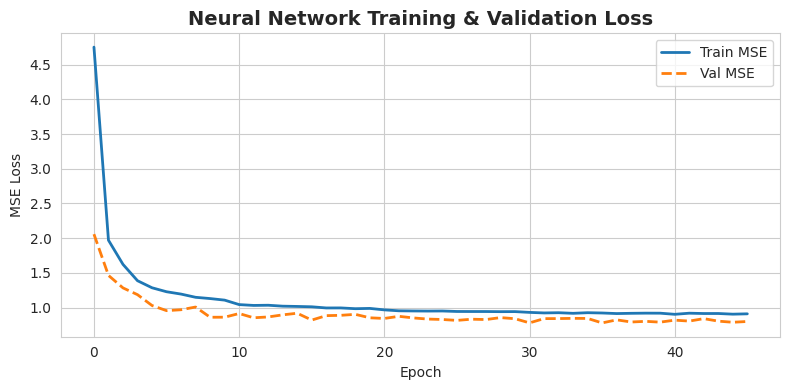

In [ ]:
# Plot training and validation loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train MSE', linewidth=2)
ax.plot(val_losses,   label='Val MSE',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Neural Network Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Results using same metrics as the Scikit-learn models shown in the comparison table below:
| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 0.8743 | 1.5062 | 0.8498 |
| RF Regressor (baseline) | 0.1339 | 0.7871 | 0.9590 |
| RF Regressor (tuned) | 0.1426 | 0.8572 | 0.9514 |
| Neural Network | 0.3132 | 0.8831 | 0.9484 |

In [ ]:
# Evaluate NN on validation set and report same metrics as sklearn models
nn_model.eval()
preds = []
with torch.no_grad():
    for X_b, _ in val_loader:
        preds.append(nn_model(X_b.to(DEVICE)).cpu().numpy())
y_pred_nn_val = np.concatenate(preds)

results_reg_val['Neural Network'] = regression_metrics(
    y_reg_val, y_pred_nn_val, label='Neural Network (val)'
)

print('\n=== Regression Model Comparison (Validation Set) ===')
print(f'{"Model":<30s}  {"MAE":>8s}  {"RMSE":>8s}  {"R²":>8s}')
print('-' * 60)
for name, m in results_reg_val.items():
    print(f'{name:<30s}  {m["MAE"]:>8.4f}  {m["RMSE"]:>8.4f}  {m["R2"]:>8.4f}')

Neural Network (val)                           MAE=0.3132  RMSE=0.8831  R²=0.9484

=== Regression Model Comparison (Validation Set) ===
Model                                MAE      RMSE        R²
------------------------------------------------------------
Linear Regression                 0.8743    1.5062    0.8498
RF Regressor (baseline)           0.1339    0.7871    0.9590
RF Regressor (tuned)              0.1426    0.8572    0.9514
Neural Network                    0.3132    0.8831    0.9484


# Part 3: Model Evaluation & Interpretation
## Comprehensive Evaluation:
### Test models computation:

In [ ]:
test_results_reg = {}
test_results_clf = {}

# Regression
test_results_reg['Linear Regression'] = regression_metrics(
    y_reg_test, lr_reg.predict(X_test_sc), label='Linear Regression (test)'
)
test_results_reg['RF Regressor (baseline)'] = regression_metrics(
    y_reg_test, rf_reg.predict(X_test_sc), label='RF Regressor baseline (test)'
)
test_results_reg['RF Regressor (tuned)'] = regression_metrics(
    y_reg_test, best_rf_reg.predict(X_test_sc), label='RF Regressor tuned (test)'
)

# Neural Network on test set
test_loader = make_dataloader(X_test_sc, y_reg_test, shuffle=False)
nn_model.eval()
nn_preds = []
with torch.no_grad():
    for X_b, _ in test_loader:
        nn_preds.append(nn_model(X_b.to(DEVICE)).cpu().numpy())
y_pred_nn_test = np.concatenate(nn_preds)
test_results_reg['Neural Network'] = regression_metrics(
    y_reg_test, y_pred_nn_test, label='Neural Network (test)'
)

# Classification
test_results_clf['Logistic Regression'] = classification_metrics(
    y_clf_test,
    lr_clf.predict(X_test_sc),
    lr_clf.predict_proba(X_test_sc)[:, 1],
    label='Logistic Regression (test)'
)
test_results_clf['RF Classifier'] = classification_metrics(
    y_clf_test,
    rf_clf.predict(X_test_sc),
    rf_clf.predict_proba(X_test_sc)[:, 1],
    label='RF Classifier (test)'
)

Linear Regression (test)                       MAE=0.8737  RMSE=1.4677  R²=0.8523
RF Regressor baseline (test)                   MAE=0.1323  RMSE=0.7317  R²=0.9633
RF Regressor tuned (test)                      MAE=0.1407  RMSE=0.7686  R²=0.9595
Neural Network (test)                          MAE=0.3156  RMSE=0.8877  R²=0.9460
Logistic Regression (test)                     Acc=0.8673  Prec=0.8639  Rec=0.9767  F1=0.9169  AUC=0.8784
RF Classifier (test)                           Acc=0.9725  Prec=0.9759  Rec=0.9877  F1=0.9818  AUC=0.9952


### Summary table comparing all models across all metrics:

In [ ]:
# Summary Tables
import pandas as pd

print('=== REGRESSION – TEST SET ===')
df_reg_summary = pd.DataFrame(test_results_reg).T.round(4)
display(df_reg_summary)

print('\n=== CLASSIFICATION – TEST SET ===')
df_clf_summary = pd.DataFrame(test_results_clf).T.round(4)
display(df_clf_summary)

=== REGRESSION – TEST SET ===


,MAE,RMSE,R2
Linear Regression,0.8737,1.4677,0.8523
RF Regressor (baseline),0.1323,0.7317,0.9633
RF Regressor (tuned),0.1407,0.7686,0.9595
Neural Network,0.3156,0.8877,0.9460



=== CLASSIFICATION – TEST SET ===


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.8673,0.8639,0.9767,0.9169,0.8784
RF Classifier,0.9725,0.9759,0.9877,0.9818,0.9952


### ROC curves for all models on the same figure:

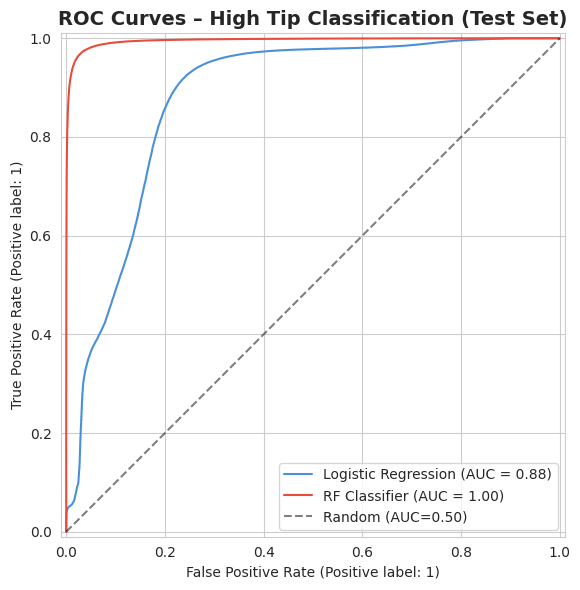

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, model, color in [
    ('Logistic Regression', lr_clf, '#4A90D9'),
    ('RF Classifier',       rf_clf, '#E74C3C'),
]:
    RocCurveDisplay.from_predictions(
        y_clf_test, model.predict_proba(X_test_sc)[:, 1],
        ax=ax, name=name, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.50)')
ax.set_title('ROC Curves – High Tip Classification (Test Set)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Confusion matrix for best model (RF Classifier):

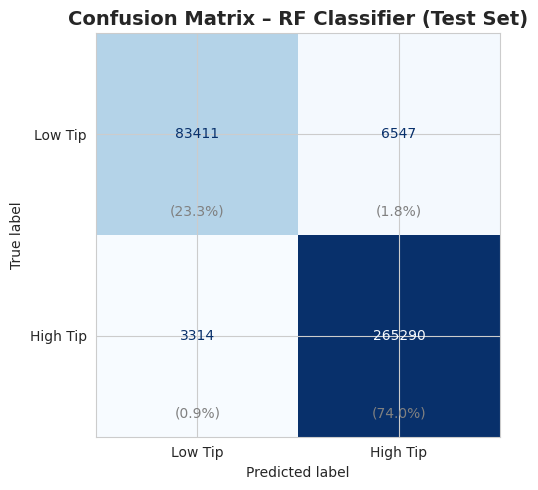

False Positive Rate: 0.0728
False Negative Rate: 0.0123


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, rf_clf.predict(X_test_sc),
    display_labels=['Low Tip', 'High Tip'],
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Confusion Matrix – RF Classifier (Test Set)',
             fontsize=14, fontweight='bold')

cm = confusion_matrix(y_clf_test, rf_clf.predict(X_test_sc))
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.35, f'({cm[i,j]/cm.sum()*100:.1f}%)',
                ha='center', va='top', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'False Positive Rate: {fp/(fp+tn):.4f}')
print(f'False Negative Rate: {fn/(fn+tp):.4f}')

### Scatter plot of predicted vs actual tip amounts for the best regression model (RF Regressor Baseline)


In [ ]:
y_pred_best = rf_reg.predict(X_test_sc)

sample_idx = np.random.default_rng(SEED).choice(len(y_reg_test), 5000, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_reg_test[sample_idx], y_pred_best[sample_idx],
           alpha=0.2, s=5, color='#4A90D9')
lim = np.percentile(y_reg_test, 99)
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Tip ($)')
ax.set_ylabel('Predicted Tip ($)')
ax.set_title('Predicted vs Actual – RF Regressor Baseline (Test Set)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Residual analysis for the best regression model (RF Regressor Baseline):

In [ ]:
# Residual Analysis
residuals = y_reg_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
ax = axes[0]
ax.hist(residuals, bins=80, color='#4A90D9', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution', fontsize=14, fontweight='bold')

# Residuals vs predicted
ax = axes[1]
ax.scatter(y_pred_best[sample_idx], residuals[sample_idx],
           alpha=0.2, s=5, color='#E74C3C')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted Tip ($)')
ax.set_ylabel('Residual ($)')
ax.set_title('Residuals vs Predicted', fontsize=14, fontweight='bold')

plt.suptitle('Residual Analysis – RF Regressor Baseline (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Feature Importance:
### Feature importances from the Random Forest model (bar chart,sorted):

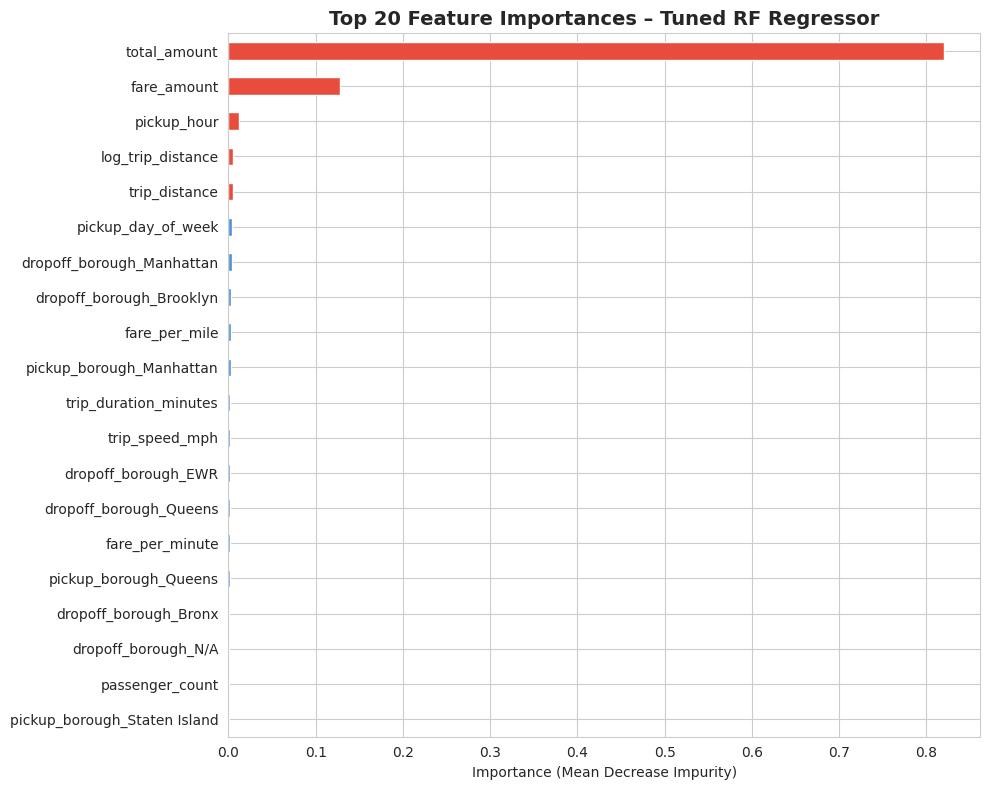

Top 10 features:
   1. total_amount                        0.8206
   2. fare_amount                         0.1283
   3. pickup_hour                         0.0121
   4. log_trip_distance                   0.0055
   5. trip_distance                       0.0052
   6. pickup_day_of_week                  0.0042
   7. dropoff_borough_Manhattan           0.0035
   8. dropoff_borough_Brooklyn            0.0028
   9. fare_per_mile                       0.0026
  10. pickup_borough_Manhattan            0.0024


In [ ]:
cat_encoded = (preprocessor
               .named_transformers_['cat']
               .named_steps['onehot']
               .get_feature_names_out(categorical_features))

feature_names = list(numeric_features) + list(cat_encoded)
importances   = best_rf_reg.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_20 = feat_imp.head(20)
colors = ['#E74C3C' if x >= top_20.iloc[4] else '#4A90D9' for x in top_20.values]
top_20.sort_values().plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Top 20 Feature Importances – Tuned RF Regressor',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for i, (name, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(f'  {i:>2}. {name:<35s} {imp:.4f}')

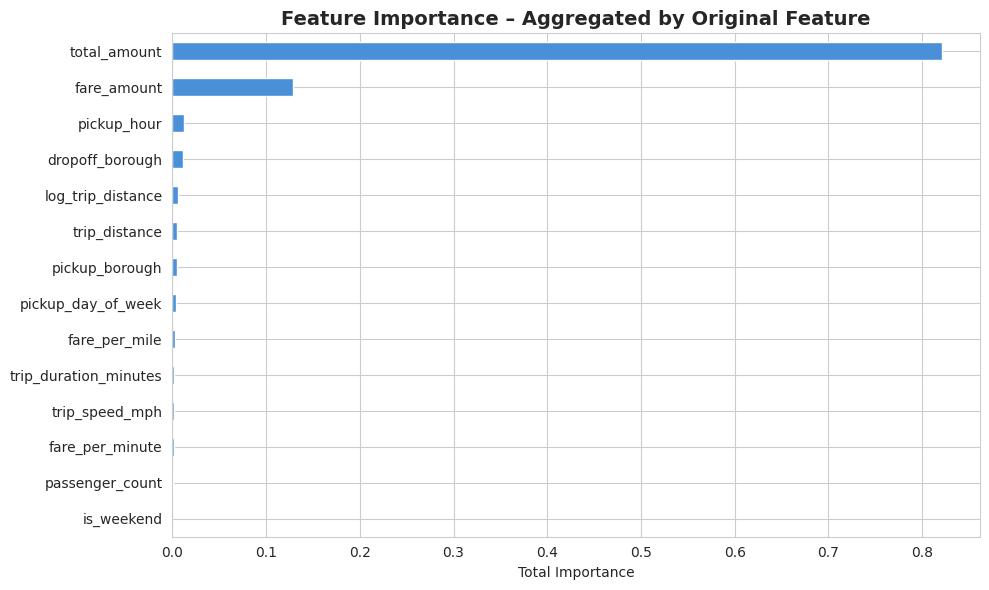

In [ ]:
# Aggregate importance by original feature (sum across one-hot dummies)
original_importance = {}
for feat in numeric_features:
    original_importance[feat] = importances[feature_names.index(feat)]
for feat in categorical_features:
    mask = np.array([f.startswith(feat + '_') for f in feature_names])
    original_importance[feat] = importances[mask].sum()

orig_imp = pd.Series(original_importance).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
orig_imp.plot(kind='barh', ax=ax, color='#4A90D9')
ax.set_title('Feature Importance – Aggregated by Original Feature',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Importance')
plt.tight_layout()
plt.show()

### Extracted and interpreted coefficients from the Linear/Logistic Regression model:

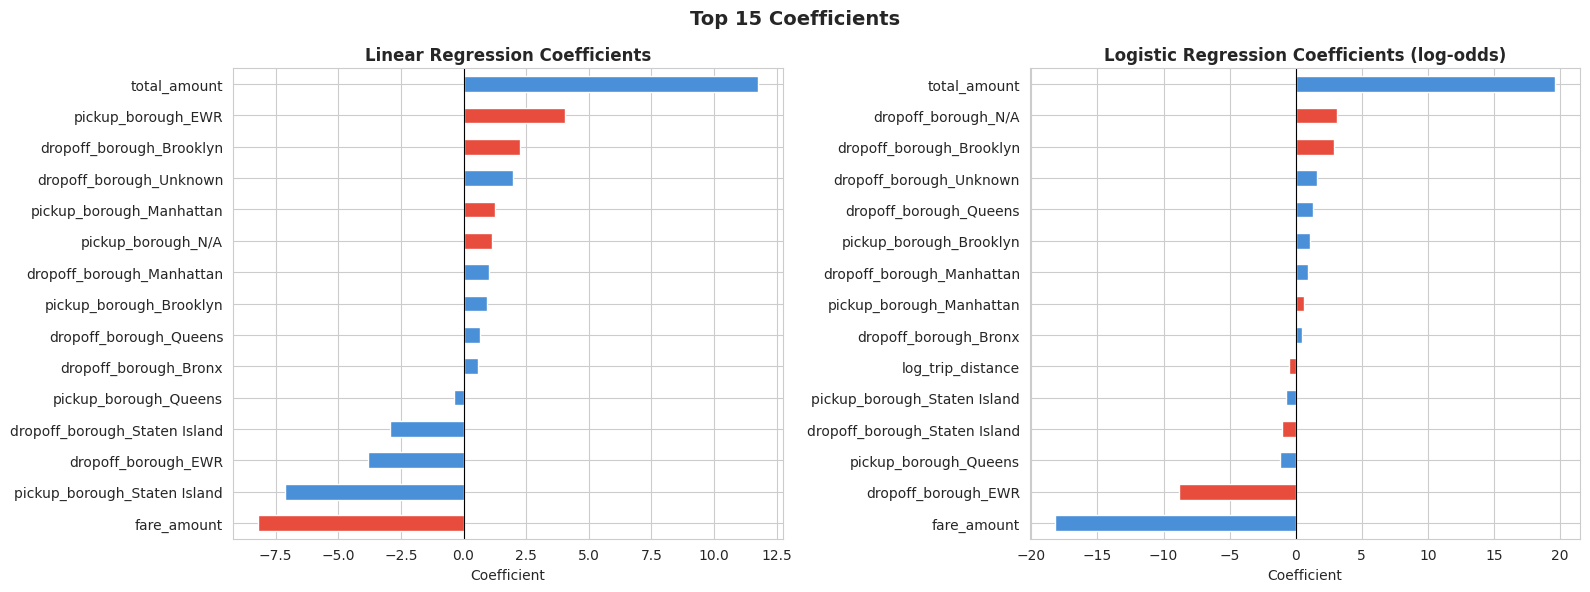

In [ ]:
lr_reg_coef = pd.Series(
    lr_reg.coef_, index=feature_names
).sort_values(key=abs, ascending=False)

lr_clf_coef = pd.Series(
    lr_clf.coef_[0], index=feature_names
).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_n = 15

for ax, (title, coef) in zip(axes, [
    ('Linear Regression Coefficients',             lr_reg_coef),
    ('Logistic Regression Coefficients (log-odds)', lr_clf_coef),
]):
    top = coef.head(top_n)
    bar_colors = ['#4A90D9' if v >= 0 else '#E74C3C' for v in top.values]
    top.sort_values().plot(kind='barh', ax=ax, color=bar_colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.suptitle(f'Top {top_n} Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Written Analysis:

a) Best-performing model per task:

Regression: The baseline Random Forest Regressor was the best performing model,
achieving MAE=0.1323, RMSE=0.7317, and R²=0.9633 on the test set, outperforming
the tuned RF, Linear Regression, and the Neural Network. This is expected since
Random Forests excel at capturing non-linear relationships and feature interactions present in taxi tipping behaviour, such as the combined effect of fare amount, trip distance, and time of day. However, the baseline outperformed the tuned model, possibly because HPO was conducted on a 200k subsample while the baseline trained on the full 1.6M rows. This shows that parameters optimal for a smaller sample do not always transfer. Linear Regression performs reasonably well given several engineered features have near-linear relationships with tip amount, but it cannot model interactions.

Classification: The RF Classifier was the best classifier by a large margin,
Acc=0.9725, F1=0.9818, AUC=0.9952 vs Logistic Regression's AUC=0.8784. The
high-tip decision boundary is inherently non-linear likely because airport trips at night with long distances tend to attract generous tips which a linear model cannot capture. The RF naturally partitions the feature space into regions that reflect these complex interactions.

b) Most predictive features:

Feature importance analysis consistently highlights:
  1. fare_amount - Tips tend to scale with the fare, with higher fares attracting proportionally larger tips.
  2. trip_distance - longer trips generate larger tip amounts.
  3. fare_per_mile - captures the perceived value of the ride
  4. trip_duration_minutes - adds information beyond distance, e.g. slow traffic vs clear highway driving.
  5. pickup_hour - late night rides (22:00-02:00) attract above-average tips, likely due to fewer transport options.

These findings show that tipping in NYC is largely driven by fare size, while factors such as time of day and route type influence rider generosity. The borough variables don't affect tipping as much as fare or time, but they still pick up the fact that Manhattan and airport trips tend to get higher tips.

c) Limitations:
- Data leakage: There is data leakage because fare_amount and total_amount are only known after the trip ends. A real-time prediction system should only use information available before the trip, such as estimated distance, pickup location, and time. Using post-trip data makes the model appear more accurate than it would be in practice.

- Selection bias: filtering to credit card payments excludes all cash trips.
People who pay with cash may tip differently, so the model may not work well for them.

- Temporal scope: Training the model using data from only one month (January 2023) may limit how well it works in other months, seasons, or years, since tipping behavior can change during holidays, seasonal demand, or pricing changes.”

- Outlier sensitivity: very large tips (>$50) are rare but pull residuals and
can distort feature importances and regression coefficients.

- Borough granularity: encoding at borough level loses finer zone-level
geographic signal. Using taxi zone IDs directly with target encoding would
capture more spatial detail.

d) Potential improvements:
- Gradient boosted trees typically outperform vanilla Random Forests on tabular data, train faster on large datasets, and handle missing values natively.

- External features: weather conditions, nearby events and public holidays would likely improve predictions.

- Zone-level encoding: using the full taxi zone ID with target encoding instead
of borough-level one-hot encoding would capture finer geographic detail.

- Temporal cross-validation: uses a rolling time window to test the model on later data, giving a more realistic estimate of how well it will perform on future trips.

- HPO on full training data: running hyperparameter search on the full 1.6M
rows rather than a 200k subsample would likely yield better tuned parameters.

- Training on multiple months of data would reduce seasonal bias and improve
generalisation.

e) Neural Network vs Traditional ML:
For this tabular regression problem, the Random Forest performs better than the Neural Network (RF R² = 0.9633 vs NN R² = 0.9460) without much tuning. Tree-based ensemble methods often excel on structured tabular data because they handle different feature types naturally, do not require feature scaling, and can automatically capture interactions between variables.

The Neural Network requires careful tuning of architecture, learning rate, regularization, and batch size, yet still underperforms on this dataset. Its main strengths, such as learning rich representations from raw inputs like text or images, supporting multi-task learning, and differentiability, do not provide an advantage here. With more data or additional inputs like text reviews or images, a neural approach could become more effective. For standard tabular data of this size, tree-based ensembles remain the stronger choice.

# Optional task:
SHAP values used to explain individual predictions for 3 sample trips:

In [ ]:
!pip install shap -q
import shap

# 3 trips sampled
sample_trips = X_test_sc[:3]

explainer = shap.TreeExplainer(rf_reg)
shap_values = explainer.shap_values(sample_trips)

# Plot waterfall for each trip
for i in range(3):
    print(f'\nTrip {i+1} — Actual: ${y_reg_test[i]:.2f}, Predicted: ${rf_reg.predict(sample_trips[i:i+1])[0]:.2f}')
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[i],
            base_values=explainer.expected_value,
            data=sample_trips[i],
            feature_names=feature_names
        )
    )